In [ ]:
import random
import datetime

# This script creates a fake log file with some injected anomalies
# In real life, this would be your actual server/app log

output_file = "server.log"
lines = []

start_time = datetime.datetime(2026, 3, 25, 0, 0, 0)

print("Generating sample log file...")

for i in range(500):
    # Every line gets a timestamp, 1 second apart
    timestamp = start_time + datetime.timedelta(seconds=i * 30)
    ts = timestamp.strftime("%Y-%m-%d %H:%M:%S")

    # Inject anomalies at specific points
    is_anomaly = i in [120, 121, 122, 123, 300, 301, 450]

    if is_anomaly:
        # Anomaly: flood of errors
        for _ in range(random.randint(20, 40)):
            lines.append(f"{ts} ERROR  Database connection refused - too many connections")
            lines.append(f"{ts} ERROR  Request timeout after 30000ms")
            lines.append(f"{ts} WARN   Memory usage critical: {random.randint(90, 99)}%")
        lines.append(f"{ts} ERROR  Service crashed - attempting restart")
    else:
        # Normal: mix of INFO with occasional warn/error
        num_lines = random.randint(3, 8)
        for _ in range(num_lines):
            level_choice = random.choices(
                ["INFO", "INFO", "INFO", "INFO", "WARN", "ERROR"],
                weights=[60, 60, 60, 60, 15, 5],
                k=1
            )[0]

            if level_choice == "INFO":
                msg = random.choice([
                    "Request processed successfully in 120ms",
                    "User login successful",
                    "Cache hit for key: user_session",
                    "Health check passed",
                    "Metrics exported to Prometheus",
                    "Scheduled job completed"
                ])
            elif level_choice == "WARN":
                msg = random.choice([
                    "Response time above 500ms",
                    "Cache miss - fetching from database",
                    "Retry attempt 1 of 3"
                ])
            else:
                msg = random.choice([
                    "Failed to parse request body",
                    "Authentication token expired"
                ])

            lines.append(f"{ts} {level_choice:<6} {msg}")

# Write to file
with open(output_file, "w") as f:
    f.write("\n".join(lines))

print(f"Generated {len(lines)} log lines in {output_file}")
print(f"Anomalies injected at positions: 120, 121, 122, 123, 300, 301, 450")

Generating sample log file...
Generated 3281 log lines in server.log
Anomalies injected at positions: 120, 121, 122, 123, 300, 301, 450


In [ ]:
import re
import pandas as pd
from datetime import datetime

def parse_log_file(filepath):
    """
    Read a log file and turn each line into structured data.

    Input:  raw log file like:
            "2026-03-25 00:00:00 ERROR  Database connection refused"

    Output: pandas DataFrame with columns:
            timestamp | level | message
    """
    # Regular expression to match log line format:
    # Group 1: date and time  → 2026-03-25 00:00:00
    # Group 2: log level      → ERROR
    # Group 3: message        → Database connection refused
    pattern = r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})\s+(INFO|WARN|ERROR|DEBUG)\s+(.*)'
    # \d{4} = exactly 4 digits
    # -      = literal dash
    # \s+    = one or more spaces
    # (.*)   = anything (the message)

    records = []  # list to store parsed lines

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()           # remove \n at end
            if not line:                  # skip empty lines
                continue

            match = re.match(pattern, line)  # try to match pattern
            if match:
                timestamp_str = match.group(1)   # "2026-03-25 00:00:00"
                level         = match.group(2)   # "ERROR"
                message       = match.group(3)   # "Database connection..."

                # Convert string to actual datetime object
                timestamp = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S")

                records.append({
                    "timestamp": timestamp,
                    "level":     level,
                    "message":   message
                })

    # Convert list of dicts to pandas DataFrame
    df = pd.DataFrame(records)

    print(f"Parsed {len(df)} log lines")
    print(f"Columns: {list(df.columns)}")
    print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"\nLevel counts:")
    print(df['level'].value_counts())

    return df

In [ ]:
parse_log_file('server.log')

Parsed 3310 log lines
Columns: ['timestamp', 'level', 'message']
Time range: 2026-03-25 00:00:00 to 2026-03-25 04:09:30

Level counts:
level
INFO     2467
ERROR     471
WARN      372
Name: count, dtype: int64


,timestamp,level,message
0,2026-03-25 00:00:00,INFO,User login successful
1,2026-03-25 00:00:00,INFO,Cache hit for key: user_session
2,2026-03-25 00:00:00,INFO,Request processed successfully in 120ms
3,2026-03-25 00:00:00,INFO,Metrics exported to Prometheus
4,2026-03-25 00:00:00,INFO,Health check passed
...,...,...,...
3305,2026-03-25 04:09:30,INFO,Metrics exported to Prometheus
3306,2026-03-25 04:09:30,INFO,Metrics exported to Prometheus
3307,2026-03-25 04:09:30,INFO,Cache hit for key: user_session
3308,2026-03-25 04:09:30,INFO,Metrics exported to Prometheus


In [ ]:
import pandas as pd

def extract_features(df, window_minutes=1):
    """
    Convert raw log lines into numerical features per time window.

    Why? Isolation Forest only understands NUMBERS, not text.
    We need to summarize each time window as a row of numbers.

    Input:  DataFrame with timestamp, level, message columns
    Output: DataFrame where each row = one time window
            and columns = numerical features

    window_minutes: how big each time bucket is
                    1 minute = aggregate all logs in each minute
    """

    # Set timestamp as the index so we can resample by time
    df = df.set_index('timestamp')

    # resample('1min') = group all rows by 1-minute buckets
    # Like GROUP BY in SQL but by time
    grouped = df.resample(f'{window_minutes}min')

    features = []  # one dict per time window

    for window_start, window_df in grouped:
        # window_start = the start time of this 1-minute bucket
        # window_df    = all log lines in that 1 minute

        if len(window_df) == 0:
            continue   # skip empty windows

        total = len(window_df)   # total log lines in this window

        # Count each log level
        level_counts = window_df['level'].value_counts()
        error_count  = level_counts.get('ERROR', 0)  # 0 if no errors
        warn_count   = level_counts.get('WARN',  0)
        info_count   = level_counts.get('INFO',  0)

        # Calculate rates (percentages)
        error_rate = error_count / total * 100   # e.g. 25.0 means 25% errors
        warn_rate  = warn_count  / total * 100

        # Time-based features
        hour       = window_start.hour            # 0-23
        is_weekend = 1 if window_start.weekday() >= 5 else 0
        # weekday() returns: Mon=0, Tue=1, Wed=2, Thu=3, Fri=4, Sat=5, Sun=6

        # Message-based features: search for specific keywords
        messages = window_df['message'].str.lower()  # convert to lowercase
        timeout_count  = messages.str.contains('timeout').sum()
        crash_count    = messages.str.contains('crash|crashed').sum()
        memory_count   = messages.str.contains('memory').sum()
        db_error_count = messages.str.contains('database|db|connection').sum()

        features.append({
            # Time info (for reference, not used in model)
            'window_start':    window_start,

            # Count features
            'total_lines':     total,
            'error_count':     error_count,
            'warn_count':      warn_count,
            'info_count':      info_count,

            # Rate features (most important)
            'error_rate':      round(error_rate, 2),
            'warn_rate':       round(warn_rate, 2),

            # Keyword features
            'timeout_count':   int(timeout_count),
            'crash_count':     int(crash_count),
            'memory_count':    int(memory_count),
            'db_error_count':  int(db_error_count),

            # Time features
            'hour':            hour,
            'is_weekend':      is_weekend,
        })

    feature_df = pd.DataFrame(features)
    print(f"\nFeature extraction complete!")
    print(f"Total time windows: {len(feature_df)}")
    print(f"\nSample features (first 3 rows):")
    print(feature_df.head(3).to_string())

    return feature_df

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_anomalies(feature_df, contamination=0.05):
    """
    Use Isolation Forest to find anomalous time windows.

    contamination = what percentage of data we expect to be anomalies
                    0.05 = we expect 5% of windows to be anomalous
                    In production, tune this based on your system

    Returns: feature_df with 2 new columns added:
             'anomaly_score' → more negative = more anomalous
             'is_anomaly'    → True or False
    """

    # ── Step 1: Select only numerical feature columns for the model ──
    # We don't include 'window_start' because it's a datetime, not a number
    feature_columns = [
        'total_lines',
        'error_count',
        'warn_count',
        'error_rate',
        'warn_rate',
        'timeout_count',
        'crash_count',
        'memory_count',
        'db_error_count',
        'hour',
        'is_weekend'
    ]

    # Extract just the feature columns into a matrix X
    X = feature_df[feature_columns].values
    # X is now a 2D array like:
    # [[10, 0, 1, 0.0,  10.0, 0, 0, 0, 0, 14, 0],  ← window 1
    #  [8,  0, 0, 0.0,  0.0,  0, 0, 0, 0, 14, 0],  ← window 2
    #  [45, 30, 5, 66.7, 11.1, 3, 1, 2, 5, 14, 0]] ← anomaly window

    # ── Step 2: Scale the features ──────────────────────────────────
    # StandardScaler makes all features have mean=0, std=1
    # Why? Because error_count might be 0-50, but total_lines might be 0-200
    # Without scaling, large numbers would dominate the model
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # fit_transform = learn the mean/std from data, then apply the scaling

    # ── Step 3: Create and train Isolation Forest ────────────────────
    model = IsolationForest(
        n_estimators=100,          # build 100 trees
                                   # more trees = more stable results
                                   # 100 is a good default

        contamination=contamination, # expected % of anomalies
                                   # used to set the decision threshold

        max_samples='auto',        # how many samples to use per tree
                                   # 'auto' = min(256, n_samples)

        random_state=42            # seed for reproducibility
                                   # same seed = same results every run
    )

    # fit() = train the model on our data
    # It builds 100 isolation trees
    model.fit(X_scaled)
    print("Isolation Forest model trained on", len(X_scaled), "time windows")

    # ── Step 4: Get anomaly scores ───────────────────────────────────
    # score_samples() returns the anomaly score for each row
    # More NEGATIVE = more anomalous (further from normal cluster)
    # Around -0.5 or lower = anomaly
    # Around 0.0 to +0.5   = normal
    scores = model.score_samples(X_scaled)

    # predict() returns: +1 = normal, -1 = anomaly
    predictions = model.predict(X_scaled)

    # ── Step 5: Add results back to dataframe ───────────────────────
    feature_df = feature_df.copy()
    feature_df['anomaly_score'] = scores
    feature_df['is_anomaly']    = predictions == -1
    # predictions == -1 gives True/False (True = anomaly)

    # Print summary
    num_anomalies = feature_df['is_anomaly'].sum()
    print(f"\nDetection complete!")
    print(f"Total windows:    {len(feature_df)}")
    print(f"Anomalies found:  {num_anomalies}")
    print(f"Normal windows:   {len(feature_df) - num_anomalies}")

    return feature_df, model, scaler

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_results(feature_df):
    """
    Create visual charts showing:
    1. Error rate over time with anomalies highlighted
    2. Anomaly scores over time
    3. Feature breakdown of anomalous windows
    """

    # Separate anomalies from normal windows
    normal    = feature_df[~feature_df['is_anomaly']]   # ~ means NOT
    anomalies = feature_df[feature_df['is_anomaly']]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    # Create a figure with 3 subplots stacked vertically
    fig.suptitle('Log Anomaly Detection — Isolation Forest Results', fontsize=14)

    # ── Plot 1: Error rate over time ──────────────────────────────
    ax1 = axes[0]
    ax1.plot(
        normal['window_start'],
        normal['error_rate'],
        color='steelblue',
        linewidth=1,
        label='Normal'
    )
    ax1.scatter(
        anomalies['window_start'],
        anomalies['error_rate'],
        color='red',
        s=100,          # size of dots
        zorder=5,       # draw on top
        label='Anomaly',
        marker='v'      # triangle marker
    )
    ax1.set_title('Error rate over time (red = anomaly detected)')
    ax1.set_ylabel('Error rate (%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── Plot 2: Anomaly scores ─────────────────────────────────────
    ax2 = axes[1]
    colors = ['red' if a else 'steelblue' for a in feature_df['is_anomaly']]
    ax2.bar(
        feature_df['window_start'],
        feature_df['anomaly_score'],
        color=colors,
        width=0.02          # width of each bar
    )
    ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    ax2.set_title('Anomaly score per window (more negative = more anomalous)')
    ax2.set_ylabel('Anomaly score')
    ax2.grid(True, alpha=0.3)

    # ── Plot 3: Total log lines per window ─────────────────────────
    ax3 = axes[2]
    ax3.plot(
        normal['window_start'],
        normal['total_lines'],
        color='steelblue',
        linewidth=1,
        label='Normal'
    )
    ax3.scatter(
        anomalies['window_start'],
        anomalies['total_lines'],
        color='red',
        s=100,
        zorder=5,
        label='Anomaly',
        marker='v'
    )
    ax3.set_title('Total log lines per window (spikes = anomaly)')
    ax3.set_ylabel('Log line count')
    ax3.set_xlabel('Time')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight')
    print("\nChart saved as: anomaly_detection_results.png")
    plt.show()


def print_anomaly_report(feature_df):
    """
    Print a clean text report of all detected anomalies.
    This is what you'd send to your Lead Manager.
    """
    anomalies = feature_df[feature_df['is_anomaly']].copy()
    anomalies = anomalies.sort_values('anomaly_score')  # worst first

    print("\n" + "=" * 60)
    print("ANOMALY DETECTION REPORT")
    print("=" * 60)
    print(f"Scan period:     {feature_df['window_start'].min()} to {feature_df['window_start'].max()}")
    print(f"Total windows:   {len(feature_df)}")
    print(f"Anomalies found: {len(anomalies)}")
    print("=" * 60)

    if len(anomalies) == 0:
        print("No anomalies detected. System looks healthy!")
        return

    print("\nDetailed anomaly breakdown:")
    print("-" * 60)

    for _, row in anomalies.iterrows():
        print(f"\nTime:          {row['window_start']}")
        print(f"Anomaly score: {row['anomaly_score']:.4f}  (lower = worse)")
        print(f"Total logs:    {row['total_lines']}")
        print(f"Errors:        {row['error_count']} ({row['error_rate']:.1f}%)")
        print(f"Warnings:      {row['warn_count']} ({row['warn_rate']:.1f}%)")
        if row['crash_count'] > 0:
            print(f"Crashes:       {row['crash_count']} CRASH EVENTS DETECTED!")
        if row['timeout_count'] > 0:
            print(f"Timeouts:      {row['timeout_count']}")
        if row['db_error_count'] > 0:
            print(f"DB errors:     {row['db_error_count']}")
        print(f"Severity:      {'CRITICAL' if row['error_rate'] > 50 else 'HIGH'}")

AIOps Log Anomaly Detector — Isolation Forest

[1/4] Parsing log file...
Parsed 3310 log lines
Columns: ['timestamp', 'level', 'message']
Time range: 2026-03-25 00:00:00 to 2026-03-25 04:09:30

Level counts:
level
INFO     2467
ERROR     471
WARN      372
Name: count, dtype: int64

[2/4] Extracting features...

Feature extraction complete!
Total time windows: 250

Sample features (first 3 rows):
         window_start  total_lines  error_count  warn_count  info_count  error_rate  warn_rate  timeout_count  crash_count  memory_count  db_error_count  hour  is_weekend
0 2026-03-25 00:00:00           11            0           0          11         0.0        0.0              0            0             0               0     0           0
1 2026-03-25 00:01:00            8            1           0           7        12.5        0.0              0            0             0               0     0           0
2 2026-03-25 00:02:00           12            0           0          12         0.0     

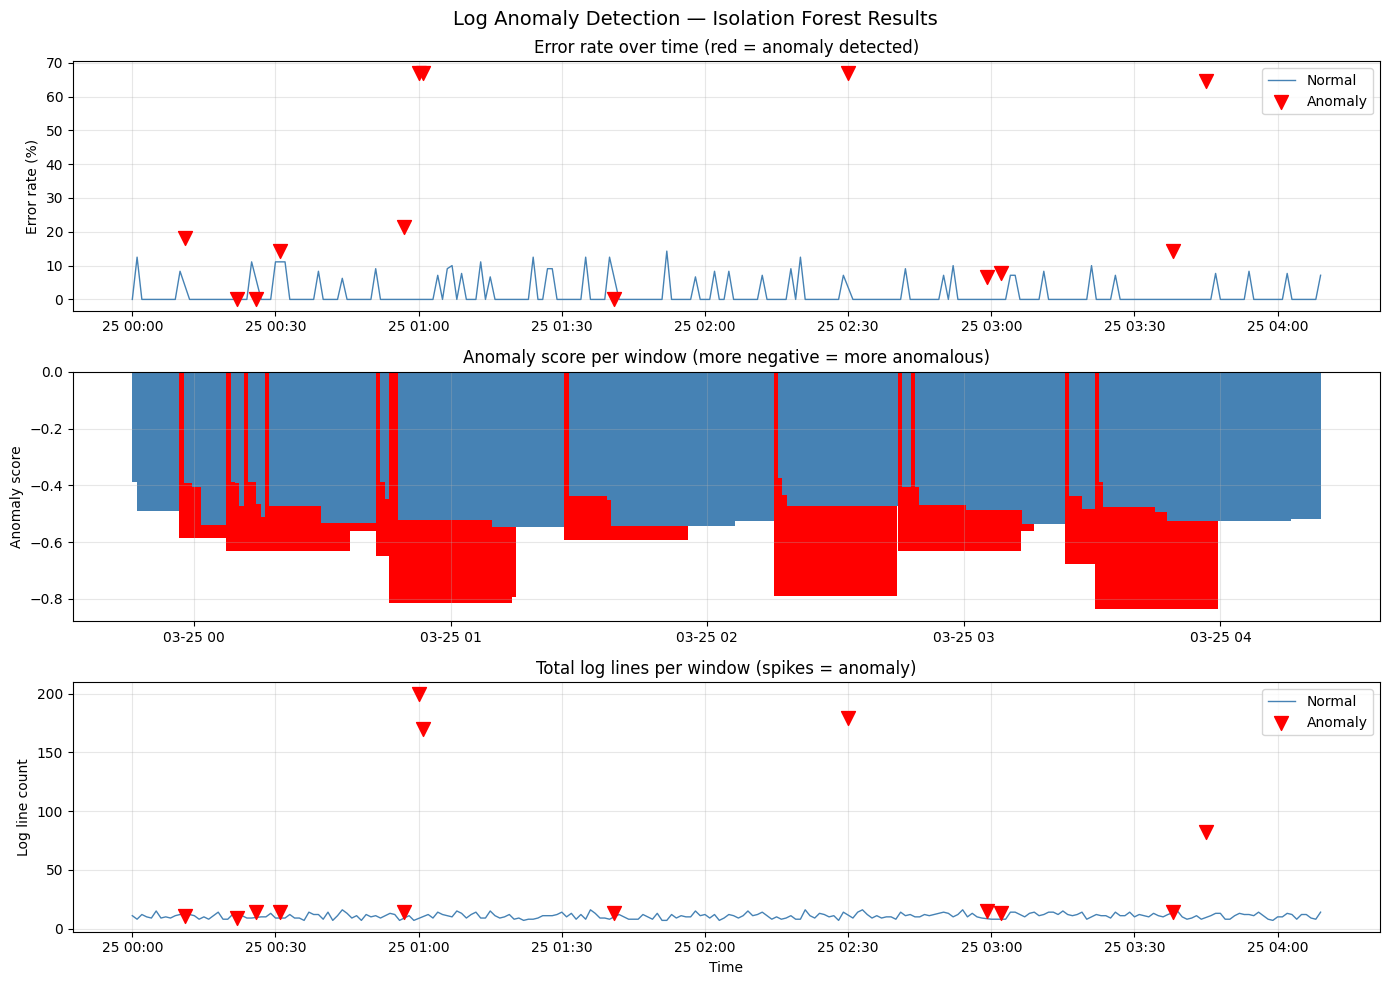


Done! Check anomaly_detection_results.png for the charts.


In [ ]:



print("=" * 60)
print("AIOps Log Anomaly Detector — Isolation Forest")
print("=" * 60)

# ── STEP 1: Parse the log file ───────────────────────────────
print("\n[1/4] Parsing log file...")
df = parse_log_file("server.log")

# ── STEP 2: Extract features from logs ──────────────────────
print("\n[2/4] Extracting features...")
feature_df = extract_features(df, window_minutes=1)

# ── STEP 3: Run Isolation Forest ────────────────────────────
print("\n[3/4] Running Isolation Forest...")
result_df, model, scaler = detect_anomalies(
    feature_df,
    contamination=0.05    # expect 5% anomalies
)

# ── STEP 4: Report and visualize ────────────────────────────
print("\n[4/4] Generating report...")
print_anomaly_report(result_df)
plot_results(result_df)

print("\nDone! Check anomaly_detection_results.png for the charts.")

What is Isolation Forest?
An unsupervised ML algorithm that detects anomalies by randomly splitting data. Points that are isolated in fewer splits are anomalies. It does not need labeled data — it learns what is normal on its own.
Why use it for logs?
Logs are high-volume and unlabeled. You cannot manually label every error as "anomaly" or "normal." Isolation Forest works without labels — you just feed it historical log data and it learns the normal pattern automatically.
What is contamination?
The expected percentage of anomalies in your data. Set to 0.05 (5%) if you expect roughly 1 in 20 windows to be abnormal. Tune this based on your system's actual error rate.
What is feature engineering here?
Converting text logs into numbers — error count, error rate, crash count — so the ML model can process them. The model cannot understand text, only numbers.

In [1]:
import pandas as pd

# Sample nested data
data = [{
  "timestamp": "2026-03-25T10:00:00Z",
  "kubernetes": {
    "pod": {
      "name": "auth-service-xyz",
      "cpu": {
        "usage": 0.85
      },
      "memory": {
        "usage": 512
      }
    },
    "node": {
      "name": "node-1"
    }
  },
  "system": {
    "cpu": {
      "total": 75
    },
    "memory": {
      "used": 68
    }
  }
}]

df = pd.json_normalize(data)

print(df.columns)

Index(['timestamp', 'kubernetes.pod.name', 'kubernetes.pod.cpu.usage',
       'kubernetes.pod.memory.usage', 'kubernetes.node.name',
       'system.cpu.total', 'system.memory.used'],
      dtype='object')


In [2]:
df = df[[
    "timestamp",
    "system.cpu.total",
    "system.memory.used"
]]

In [3]:
df.columns = ["timestamp", "cpu", "memory"]

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

In [5]:
df = df.fillna(method="ffill")

/tmp/ipykernel_3783/567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [8]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.02)

model.fit(scaled_data)

predictions = model.predict(scaled_data)

In [9]:
df["anomaly"] = predictions

anomalies = df[df["anomaly"] == -1]

print(anomalies)

Empty DataFrame
Columns: [cpu, memory, anomaly]
Index: []


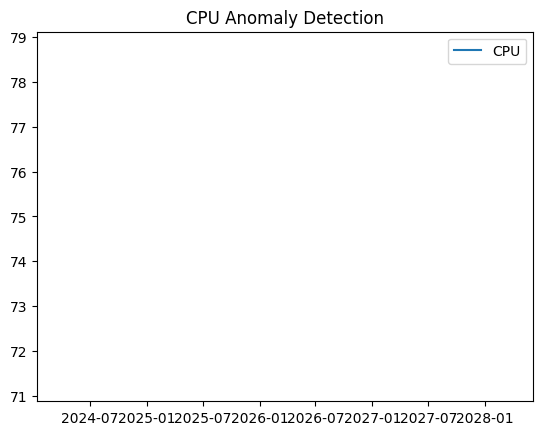

In [10]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["cpu"], label="CPU")

plt.scatter(anomalies.index, anomalies["cpu"], color='red')

plt.title("CPU Anomaly Detection")
plt.legend()
plt.show()

In [ ]:
# preprocessing.py
import json
import pandas as pd
from flatten_json import flatten  # pip install flatten_json

def flatten_metric_event(raw_json: dict) -> dict:
    """
    Flatten a nested Kubernetes/Metricbeat JSON event into a flat dict.
    Example input:
      {"kubernetes": {"pod": {"name": "api-xyz", "cpu": {"usage": 0.43}}}}
    Example output:
      {"kubernetes_pod_name": "api-xyz", "kubernetes_pod_cpu_usage": 0.43}
    """
    flat = flatten(raw_json, separator="_")
    # Keep only numeric fields + key identifiers
    filtered = {}
    for key, val in flat.items():
        if isinstance(val, (int, float)):
            filtered[key] = val
        elif key in ("kubernetes_pod_name", "kubernetes_namespace", "@timestamp"):
            filtered[key] = val
    return filtered

def parse_timestamp(event: dict) -> pd.Timestamp:
    return pd.to_datetime(event.get("@timestamp"))

# Example
raw = {
    "@timestamp": "2024-01-15T10:00:01Z",
    "kubernetes": {
        "pod": {
            "name": "api-server-abc",
            "cpu": {"usage": {"nanocores": 430_000_000}},
            "memory": {"usage": {"bytes": 512_000_000}},
        },
        "namespace": "production"
    },
    "metricset": {"name": "pod"}
}

print(flatten_metric_event(raw))
# → {'kubernetes_pod_cpu_usage_nanocores': 430000000,
#    'kubernetes_pod_memory_usage_bytes': 512000000,
#    'kubernetes_pod_name': 'api-server-abc',
#    'kubernetes_namespace': 'production',
#    '@timestamp': '2024-01-15T10:00:01Z'}

In [ ]:
# features.py
import numpy as np
import pandas as pd

NUMERIC_COLS = [
    "kubernetes_pod_cpu_usage_nanocores",
    "kubernetes_pod_memory_usage_bytes",
]

def engineer_features(df: pd.DataFrame, window: int = 60) -> pd.DataFrame:
    """
    df: time-indexed dataframe, one row per second per pod.
    window: rolling window in seconds (default 60s = 1 minute).
    """
    df = df.sort_index()
    result = df[NUMERIC_COLS].copy()

    for col in NUMERIC_COLS:
        # Rolling statistics (capture baseline and volatility)
        result[f"{col}_rolling_mean"] = df[col].rolling(window).mean()
        result[f"{col}_rolling_std"]  = df[col].rolling(window).std()
        result[f"{col}_rolling_min"]  = df[col].rolling(window).min()
        result[f"{col}_rolling_max"]  = df[col].rolling(window).max()

        # Rate of change (detect sudden spikes)
        result[f"{col}_roc_1s"]  = df[col].diff(1)   # 1-second delta
        result[f"{col}_roc_10s"] = df[col].diff(10)  # 10-second delta

        # Lag features (give the model memory)
        for lag in [1, 5, 30, 60]:
            result[f"{col}_lag_{lag}"] = df[col].shift(lag)

        # Z-score vs rolling baseline (how many std devs from "normal"?)
        mean = result[f"{col}_rolling_mean"]
        std  = result[f"{col}_rolling_std"].replace(0, 1e-9)
        result[f"{col}_zscore"] = (df[col] - mean) / std

    return result.dropna()  # Drop rows where rolling windows aren't full yet

# Usage
# df is your per-pod time-indexed dataframe
# features_df = engineer_features(df)

In [ ]:
# train.py
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

# ─── Step 1: Isolation Forest (ship this first) ───────────────────────────────

def train_isolation_forest(features_df: pd.DataFrame, contamination=0.01):
    """
    contamination: expected fraction of anomalies (1% here).
    Tune this based on your domain knowledge.
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(features_df)

    model = IsolationForest(
        n_estimators=200,       # more trees = more stable
        contamination=contamination,
        max_samples="auto",
        random_state=42,
        n_jobs=-1               # use all CPU cores
    )
    model.fit(X)

    # Log to MLflow for versioning
    with mlflow.start_run(run_name="isolation_forest_v1"):
        mlflow.log_param("contamination", contamination)
        mlflow.log_param("n_estimators", 200)
        mlflow.sklearn.log_model(model, "model")
        # Score training data — lower = more anomalous
        scores = model.score_samples(X)
        mlflow.log_metric("mean_anomaly_score", float(scores.mean()))

    return model, scaler

# ─── Step 2: Autoencoder ──────────────────────────────────────────────────────

class MetricAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        """High error = likely anomaly."""
        with torch.no_grad():
            recon = self.forward(x)
            return ((recon - x) ** 2).mean(dim=1)


def train_autoencoder(features_df: pd.DataFrame, epochs=50, lr=1e-3):
    scaler = StandardScaler()
    X = scaler.fit_transform(features_df)
    X_tensor = torch.FloatTensor(X)

    model = MetricAutoencoder(input_dim=X.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    with mlflow.start_run(run_name="autoencoder_v1"):
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            output = model(X_tensor)
            loss = loss_fn(output, X_tensor)
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0:
                mlflow.log_metric("train_loss", loss.item(), step=epoch)
                print(f"Epoch {epoch}: loss={loss.item():.4f}")

        # Set anomaly threshold = 95th percentile of reconstruction errors on training data
        model.eval()
        errors = model.reconstruction_error(X_tensor).numpy()
        threshold = float(np.percentile(errors, 95))
        mlflow.log_metric("anomaly_threshold_p95", threshold)
        mlflow.log_param("latent_dim", 16)

    return model, scaler, threshold